# Notebook 03_1 — Human-Code Phrase Evidence

**Goal:** estimate which words or short phrases are empirically associated with each final human code.

This notebook does **not** claim to recover the human coder's internal reasoning. It supports a more defensible statement:

> A phrase is plausible textual evidence for a human code when it appears disproportionately often in responses assigned that code.

The outputs from this notebook can later be pooled with LIME and SHAP explanations to identify phrases supported by (1) human-code association, (2) model-local explanations, and (3) qualitative review.


## 1. Setup and Inputs

Inputs:
- `data/decision_making.csv`: final human-coded responses and model prediction columns.
- `outputs/domain_phrase_candidates.csv`: 2-4 gram candidate phrases from Notebook 03_0.
- `data/domain_phrase_map.csv`: selected/audited phrase subset, used as a fallback if full candidates are unavailable.

Outputs:
- `outputs/phrase_code_association.csv`
- `outputs/phrase_code_top_phrases_by_code.csv`
- `outputs/phrase_code_evidence_by_response.csv`
- `outputs/phrase_code_top_evidence_by_response.csv`
- `outputs/fig_phrase_code_top_evidence.png`

- `outputs/fig_phrase_evidence_coverage_by_code.png` / `.pdf`
- `outputs/fig_phrase_evidence_by_response_length.png` / `.pdf`
- `outputs/fig_phrase_support_vs_lift.png` / `.pdf`
- `outputs/fig_phrase_code_response_examples.png` / `.pdf`

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import math
import pickle
import pathlib
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = pathlib.Path('data')
OUTPUT_DIR = pathlib.Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / 'config.pkl', 'rb') as f:
    cfg = pickle.load(f)
DECISION_CODES = cfg['DECISION_CODES']
CODE_NAMES = list(DECISION_CODES.keys())
LABEL_TO_CODE = {v: k for k, v in DECISION_CODES.items()}

dm_df = pd.read_csv(DATA_DIR / 'decision_making.csv')
if 'response_id' not in dm_df.columns:
    dm_df.insert(0, 'response_id', [f'decision_making_{i:04d}' for i in range(len(dm_df))])
if 'source_row_id' not in dm_df.columns:
    dm_df.insert(1, 'source_row_id', dm_df['response_id'])
dm_df['code_name'] = dm_df['label'].map(LABEL_TO_CODE)

candidate_path = OUTPUT_DIR / 'domain_phrase_candidates.csv'
selected_path = DATA_DIR / 'domain_phrase_map.csv'
if candidate_path.exists():
    phrase_candidates = pd.read_csv(candidate_path)
    phrase_source = candidate_path
elif selected_path.exists():
    phrase_candidates = pd.read_csv(selected_path)
    phrase_source = selected_path
else:
    raise FileNotFoundError('Run Notebook 03_0 first: no domain phrase candidate file was found.')

phrase_candidates = phrase_candidates.copy()
if 'phrase_len' not in phrase_candidates.columns:
    phrase_candidates['phrase_len'] = phrase_candidates['phrase'].str.split().str.len()
phrase_candidates = phrase_candidates[phrase_candidates['phrase_len'].between(2, 4)].copy()
phrase_candidates = phrase_candidates.drop_duplicates(['phrase', 'code_name'])

print(f'Responses: {len(dm_df)}')
print(f'Codes: {CODE_NAMES}')
print(f'Phrase source: {phrase_source}')
print(f'Candidate phrase-code rows: {len(phrase_candidates)}')
print(f'Unique phrases: {phrase_candidates["phrase"].nunique()}')
print('\nHuman code distribution:')
print(dm_df['code_name'].value_counts().reindex(CODE_NAMES).to_string())


Responses: 278
Codes: ['voluntary_informed', 'feeling_pressured', 'insufficient_info', 'too_much_info', 'no_consent']
Phrase source: outputs\domain_phrase_candidates.csv
Candidate phrase-code rows: 1109
Unique phrases: 625

Human code distribution:
code_name
voluntary_informed     36
feeling_pressured      80
insufficient_info     145
too_much_info           9
no_consent              8


## 2. Phrase-Code Association

For each candidate phrase and each human code, compute:

- `P(code | phrase)`: among responses containing the phrase, how often the human code was assigned.
- `P(code)`: baseline prevalence of that code.
- `lift`: how much more common the code is when the phrase appears.
- `odds_ratio`: smoothed odds ratio from a 2x2 phrase/code table.
- `fisher_p`: Fisher exact-test p-value for over/under-representation.

Small counts are kept visible through `phrase_doc_freq` and `class_phrase_docs`. Use support and effect size together; do not over-read one-off phrases.


In [2]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z][a-zA-Z']+")

def canonical_text(text):
    text = str(text).lower()
    replacements = {
        "didn’t": "didn't", "wasn’t": "wasn't", "weren’t": "weren't",
        "couldn’t": "couldn't", "wouldn’t": "wouldn't", "shouldn’t": "shouldn't",
        "don’t": "don't", "can't": "can't", "cant": "can't", "cannot": "cannot",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = re.sub(r"[^a-z0-9'\s]+", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def tokenize(text):
    return TOKEN_PATTERN.findall(canonical_text(text))


def canonical_phrase(phrase):
    return ' '.join(tokenize(phrase))


def phrase_pattern(phrase):
    parts = [re.escape(p) for p in canonical_phrase(phrase).split()]
    return re.compile(r'(?<![a-z0-9])' + r'\s+'.join(parts) + r'(?![a-z0-9])')

phrase_candidates['phrase'] = phrase_candidates['phrase'].map(canonical_phrase)
phrase_candidates = phrase_candidates[phrase_candidates['phrase'].str.len() > 0].copy()
phrase_candidates['normalization_policy'] = 'canonical_text_v2_shared_with_notebook_03_0'
phrase_candidates['phrase_len'] = phrase_candidates['phrase'].str.split().str.len()
phrase_candidates = phrase_candidates[phrase_candidates['phrase_len'].between(2, 4)].copy()
phrase_candidates = phrase_candidates.drop_duplicates(['phrase', 'code_name'])

texts = dm_df['response_text'].map(canonical_text).tolist()
labels = dm_df['code_name'].tolist()
N = len(dm_df)
code_totals = dm_df['code_name'].value_counts().reindex(CODE_NAMES).fillna(0).astype(int).to_dict()
base_rates = {code: code_totals[code] / N for code in CODE_NAMES}

unique_phrases = sorted(phrase_candidates['phrase'].dropna().unique())
phrase_patterns = {phrase: phrase_pattern(phrase) for phrase in unique_phrases}
phrase_presence = {}
for phrase, pat in phrase_patterns.items():
    phrase_presence[phrase] = np.array([bool(pat.search(text)) for text in texts], dtype=bool)

recognized_phrase_count = int(sum(arr.any() for arr in phrase_presence.values()))
missing_phrases = [phrase for phrase, arr in phrase_presence.items() if not arr.any()]
print(f'Recognized phrases in corpus: {recognized_phrase_count}/{len(unique_phrases)}')
if missing_phrases:
    print('Unmatched canonical phrases (first 10):', missing_phrases[:10])

assoc_rows = []
for phrase in unique_phrases:
    present = phrase_presence[phrase]
    phrase_doc_freq = int(present.sum())
    if phrase_doc_freq == 0:
        continue

    for code in CODE_NAMES:
        code_mask = dm_df['code_name'].eq(code).to_numpy()
        a = int((present & code_mask).sum())
        b = int((present & ~code_mask).sum())
        c = int((~present & code_mask).sum())
        d = int((~present & ~code_mask).sum())

        p_code_given_phrase = a / phrase_doc_freq if phrase_doc_freq else np.nan
        p_code = base_rates[code]
        lift = p_code_given_phrase / p_code if p_code > 0 else np.nan
        smoothed_odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        _, fisher_p = fisher_exact([[a, b], [c, d]], alternative='greater')

        assoc_rows.append({
            'phrase': phrase,
            'code_name': code,
            'phrase_len': len(phrase.split()),
            'phrase_doc_freq': phrase_doc_freq,
            'class_doc_total': code_totals[code],
            'class_phrase_docs': a,
            'other_phrase_docs': b,
            'p_code_given_phrase': p_code_given_phrase,
            'p_code_baseline': p_code,
            'lift': lift,
            'odds_ratio_smoothed': smoothed_odds_ratio,
            'log2_lift': np.log2(lift) if lift > 0 else np.nan,
            'fisher_p': fisher_p,
            'phrase_in_class_share': a / code_totals[code] if code_totals[code] else np.nan,
            'normalization_policy': 'canonical_text_v2_shared_with_notebook_03_0',
        })

assoc_df = pd.DataFrame(assoc_rows)
assoc_df['support_weight'] = np.log1p(assoc_df['class_phrase_docs'])
assoc_df['association_score'] = (
    (assoc_df['p_code_given_phrase'] - assoc_df['p_code_baseline']).clip(lower=0)
    * assoc_df['support_weight']
    * np.log1p(assoc_df['lift'].clip(lower=0))
)

# Benjamini-Hochberg FDR correction, used as a guardrail rather than a discovery claim.
assoc_df = assoc_df.sort_values('fisher_p').reset_index(drop=True)
m = len(assoc_df)
assoc_df['bh_rank'] = np.arange(1, m + 1)
assoc_df['fdr_bh'] = (assoc_df['fisher_p'] * m / assoc_df['bh_rank']).clip(upper=1)
assoc_df['fdr_bh'] = assoc_df['fdr_bh'][::-1].cummin()[::-1]
assoc_df['fdr_significant_0_05'] = assoc_df['fdr_bh'] <= 0.05

# Join Notebook 03_0 candidate scores for traceability.
score_cols = [c for c in ['ctfidf', 'log_odds_vs_rest', 'definition_similarity', 'evidence_score'] if c in phrase_candidates.columns]
if score_cols:
    candidate_scores = phrase_candidates[['phrase', 'code_name'] + score_cols].drop_duplicates(['phrase', 'code_name'])
    assoc_df = assoc_df.merge(candidate_scores, on=['phrase', 'code_name'], how='left')

assoc_df = assoc_df.sort_values(['association_score', 'class_phrase_docs'], ascending=[False, False]).reset_index(drop=True)
assoc_df.to_csv(OUTPUT_DIR / 'phrase_code_association.csv', index=False)

print(f'Association rows: {len(assoc_df):,}')
print(f'Raw p<0.05 rows: {int((assoc_df["fisher_p"] < 0.05).sum())}')
print(f'BH FDR<0.05 rows: {int(assoc_df["fdr_significant_0_05"].sum())}')
print(f'Min raw p: {assoc_df["fisher_p"].min():.3g}; min BH FDR: {assoc_df["fdr_bh"].min():.3g}')
display(assoc_df.head(15))


Recognized phrases in corpus: 587/625
Unmatched canonical phrases (first 10): ['back wish', 'did sweep', 'felt like lost', 'first hours', 'had positive experience', 'had sweep', 'have negative', 'have place', "if didn't", 'including sweep']


Association rows: 2,935
Raw p<0.05 rows: 48
BH FDR<0.05 rows: 0
Min raw p: 7.36e-05; min BH FDR: 0.146


,phrase,code_name,phrase_len,phrase_doc_freq,class_doc_total,class_phrase_docs,other_phrase_docs,p_code_given_phrase,p_code_baseline,lift,...,normalization_policy,support_weight,association_score,bh_rank,fdr_bh,fdr_significant_0_05,ctfidf,log_odds_vs_rest,definition_similarity,evidence_score
0,vaginal exam,no_consent,2,2,8,2,0,1.000000,0.028777,34.750000,...,canonical_text_v2_shared_with_notebook_03_0,1.098612,3.816170,3,0.392029,False,0.026406,4.826416,0.000000,0.800000
1,are lots,too_much_info,2,2,9,2,0,1.000000,0.032374,30.888889,...,canonical_text_v2_shared_with_notebook_03_0,1.098612,3.680538,4,0.392029,False,0.044414,5.364403,0.000000,0.541240
2,positive stories,too_much_info,2,2,9,2,0,1.000000,0.032374,30.888889,...,canonical_text_v2_shared_with_notebook_03_0,1.098612,3.680538,5,0.392029,False,0.044414,5.364403,0.213201,0.641240
3,negative stories,too_much_info,2,2,9,2,0,1.000000,0.032374,30.888889,...,canonical_text_v2_shared_with_notebook_03_0,1.098612,3.680538,6,0.392029,False,0.044414,5.364403,0.426401,0.741240
4,there are lots,too_much_info,3,2,9,2,0,1.000000,0.032374,30.888889,...,canonical_text_v2_shared_with_notebook_03_0,1.098612,3.680538,7,0.392029,False,0.044414,5.364403,0.000000,0.541240
5,my decision,voluntary_informed,2,3,36,3,0,1.000000,0.129496,7.722222,...,canonical_text_v2_shared_with_notebook_03_0,1.386294,2.613721,8,0.701149,False,0.015014,4.187553,0.277350,0.621173
6,had not,no_consent,2,1,8,1,0,1.000000,0.028777,34.750000,...,canonical_text_v2_shared_with_notebook_03_0,0.693147,2.407735,36,1.000000,False,0.013203,3.215083,0.000000,0.266432
7,be positive,too_much_info,2,1,9,1,0,1.000000,0.032374,30.888889,...,canonical_text_v2_shared_with_notebook_03_0,0.693147,2.322161,37,1.000000,False,0.022207,3.751825,0.000000,0.191116
8,women know,too_much_info,2,1,9,1,0,1.000000,0.032374,30.888889,...,canonical_text_v2_shared_with_notebook_03_0,0.693147,2.322161,38,1.000000,False,0.022207,3.751825,0.000000,0.191116
9,was happy,voluntary_informed,2,8,36,6,2,0.750000,0.129496,5.791667,...,canonical_text_v2_shared_with_notebook_03_0,1.945910,2.313097,1,0.145901,False,0.036526,3.580886,0.000000,0.761623


## 3. Strong Phrases Per Human Code

The table below is the clearest evidence layer: phrases that appear at least twice in a code and are more common than the code baseline.


In [3]:
MIN_CLASS_PHRASE_DOCS = 2
MIN_LIFT = 1.25

strong_assoc_df = assoc_df[
    (assoc_df['class_phrase_docs'] >= MIN_CLASS_PHRASE_DOCS) &
    (assoc_df['lift'] >= MIN_LIFT) &
    (assoc_df['association_score'] > 0)
].copy()

top_phrases_by_code = (
    strong_assoc_df
    .sort_values(['code_name', 'association_score', 'class_phrase_docs'], ascending=[True, False, False])
    .groupby('code_name', group_keys=False)
    .head(12)
    .reset_index(drop=True)
)

top_phrases_by_code.to_csv(OUTPUT_DIR / 'phrase_code_top_phrases_by_code.csv', index=False)

print(f'Saved top phrase evidence by code: {OUTPUT_DIR / "phrase_code_top_phrases_by_code.csv"}')
for code in CODE_NAMES:
    subset = top_phrases_by_code[top_phrases_by_code['code_name'] == code]
    print(f'\n{code}')
    if subset.empty:
        print('  No phrases met the support/lift thresholds.')
        continue
    display_cols = ['phrase', 'class_phrase_docs', 'phrase_doc_freq', 'p_code_given_phrase', 'p_code_baseline', 'lift', 'association_score']
    display(subset[display_cols].head(10))


Saved top phrase evidence by code: outputs\phrase_code_top_phrases_by_code.csv

voluntary_informed


,phrase,class_phrase_docs,phrase_doc_freq,p_code_given_phrase,p_code_baseline,lift,association_score
36,my decision,3,3,1.00,0.129496,7.722222,2.613721
37,was happy,6,8,0.75,0.129496,5.791667,2.313097
38,no sign,2,2,1.00,0.129496,7.722222,2.071325
39,never felt,2,2,1.00,0.129496,7.722222,2.071325
40,very pleased,2,2,1.00,0.129496,7.722222,2.071325
41,pleasant experience,2,2,1.00,0.129496,7.722222,2.071325
42,no sign of labour,2,2,1.00,0.129496,7.722222,2.071325
43,labour starting,2,2,1.00,0.129496,7.722222,2.071325
44,am really,2,2,1.00,0.129496,7.722222,2.071325
45,was very pleased,2,2,1.00,0.129496,7.722222,2.071325



feeling_pressured


,phrase,class_phrase_docs,phrase_doc_freq,p_code_given_phrase,p_code_baseline,lift,association_score
0,too much,4,4,1.000000,0.28777,3.475000,1.717723
1,want an induction,3,3,1.000000,0.28777,3.475000,1.479566
2,say no,3,3,1.000000,0.28777,3.475000,1.479566
3,very hard,3,3,1.000000,0.28777,3.475000,1.479566
4,be left,3,3,1.000000,0.28777,3.475000,1.479566
5,it felt like,3,3,1.000000,0.28777,3.475000,1.479566
6,felt pressured,5,6,0.833333,0.28777,2.895833,1.329335
7,it felt,5,6,0.833333,0.28777,2.895833,1.329335
8,felt like,8,11,0.727273,0.28777,2.527273,1.217272
9,hospital setting,2,2,1.000000,0.28777,3.475000,1.172529



insufficient_info


,phrase,class_phrase_docs,phrase_doc_freq,p_code_given_phrase,p_code_baseline,lift,association_score
12,waters broke,5,5,1.0,0.521583,1.917241,0.917761
13,be given,5,5,1.0,0.521583,1.917241,0.917761
14,information given,5,5,1.0,0.521583,1.917241,0.917761
15,didn't know,5,5,1.0,0.521583,1.917241,0.917761
16,be offered,4,4,1.0,0.521583,1.917241,0.824373
17,was born,4,4,1.0,0.521583,1.917241,0.824373
18,not informed,4,4,1.0,0.521583,1.917241,0.824373
19,be explained,4,4,1.0,0.521583,1.917241,0.824373
20,not prepared,4,4,1.0,0.521583,1.917241,0.824373
21,my waters broke,4,4,1.0,0.521583,1.917241,0.824373



too_much_info


,phrase,class_phrase_docs,phrase_doc_freq,p_code_given_phrase,p_code_baseline,lift,association_score
28,are lots,2,2,1.000000,0.032374,30.888889,3.680538
29,positive stories,2,2,1.000000,0.032374,30.888889,3.680538
30,negative stories,2,2,1.000000,0.032374,30.888889,3.680538
31,there are lots,2,2,1.000000,0.032374,30.888889,3.680538
32,is not,2,3,0.666667,0.032374,20.592593,2.140942
33,about inductions,4,10,0.400000,0.032374,12.355556,1.533571
34,birth experience,2,4,0.500000,0.032374,15.444444,1.438464
35,positive experiences,2,4,0.500000,0.032374,15.444444,1.438464



no_consent


,phrase,class_phrase_docs,phrase_doc_freq,p_code_given_phrase,p_code_baseline,lift,association_score
24,vaginal exam,2,2,1.000000,0.028777,34.750000,3.816170
25,no consent,2,3,0.666667,0.028777,23.166667,2.232009
26,my water,2,4,0.500000,0.028777,17.375000,1.506995
27,feel like,2,14,0.142857,0.028777,4.964286,0.223813


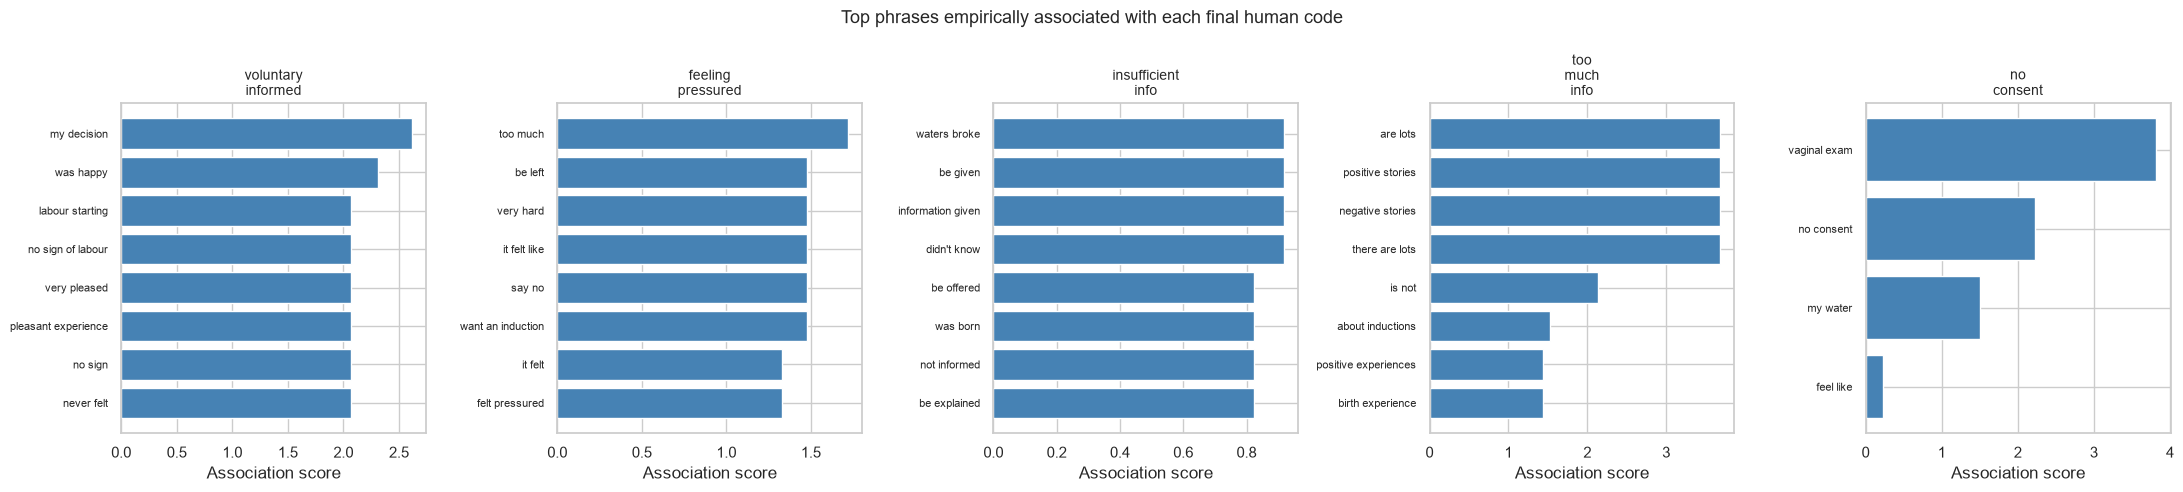

In [4]:
fig, axes = plt.subplots(1, len(CODE_NAMES), figsize=(22, 5), sharex=False)

for ax, code in zip(axes, CODE_NAMES):
    subset = top_phrases_by_code[top_phrases_by_code['code_name'] == code].head(8).copy()
    if subset.empty:
        ax.text(0.5, 0.5, 'No supported phrases', ha='center', va='center')
        ax.set_title(code.replace('_', '\n'))
        ax.axis('off')
        continue
    subset = subset.sort_values('association_score')
    ax.barh(subset['phrase'], subset['association_score'], color='steelblue')
    ax.set_title(code.replace('_', '\n'), fontsize=10)
    ax.set_xlabel('Association score')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top phrases empirically associated with each final human code', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phrase_code_top_evidence.png', dpi=180, bbox_inches='tight')
plt.show()


## 4. Per-Response Plausible Coding Evidence

For every response, find phrases present in the text and keep those empirically associated with that response's final human code.

This supports cautious case-level language such as:

This response contains phrases that are disproportionately associated with the assigned human code.


In [5]:
# Keep association rows that are interpretable enough for per-response evidence.
evidence_assoc = assoc_df[
    (assoc_df['class_phrase_docs'] >= MIN_CLASS_PHRASE_DOCS) &
    (assoc_df['lift'] >= MIN_LIFT) &
    (assoc_df['association_score'] > 0)
].copy()

assoc_lookup = {
    (row.phrase, row.code_name): row
    for row in evidence_assoc.itertuples(index=False)
}

evidence_rows = []
for row_idx, row in dm_df.iterrows():
    assigned_code = row['code_name']

    present_phrases = [phrase for phrase, present in phrase_presence.items() if present[row_idx]]
    for phrase in present_phrases:
        assoc_row = assoc_lookup.get((phrase, assigned_code))
        if assoc_row is None:
            continue
        evidence_rows.append({
            'row_index': row_idx,
            'doc_idx': row_idx,
            'assigned_code': assigned_code,
            'phrase': phrase,
            'phrase_len': assoc_row.phrase_len,
            'class_phrase_docs': assoc_row.class_phrase_docs,
            'phrase_doc_freq': assoc_row.phrase_doc_freq,
            'p_code_given_phrase': assoc_row.p_code_given_phrase,
            'p_code_baseline': assoc_row.p_code_baseline,
            'lift': assoc_row.lift,
            'odds_ratio_smoothed': assoc_row.odds_ratio_smoothed,
            'fisher_p': assoc_row.fisher_p,
            'association_score': assoc_row.association_score,
            'response_text': row['response_text'],
        })

phrase_code_evidence_df = pd.DataFrame(evidence_rows)
if phrase_code_evidence_df.empty:
    raise RuntimeError('No per-response phrase evidence found. Lower thresholds or rerun Notebook 03_0 phrase extraction.')

phrase_code_evidence_df = phrase_code_evidence_df.sort_values(
    ['row_index', 'association_score', 'class_phrase_docs'],
    ascending=[True, False, False]
).reset_index(drop=True)
phrase_code_evidence_df.to_csv(OUTPUT_DIR / 'phrase_code_evidence_by_response.csv', index=False)

summary_rows = []
for row_idx, group in phrase_code_evidence_df.groupby('row_index'):
    top = group.sort_values('association_score', ascending=False).head(5)
    summary_rows.append({
        'row_index': row_idx,
        'assigned_code': top['assigned_code'].iloc[0],
        'n_supporting_phrases': len(group),
        'top_phrases': '; '.join(top['phrase'].tolist()),
        'top_phrase_stats': '; '.join(
            f"{r.phrase} (P(code|phrase)={r.p_code_given_phrase:.2f}, lift={r.lift:.2f}, n={int(r.class_phrase_docs)})"
            for r in top.itertuples(index=False)
        ),
        'best_association_score': top['association_score'].iloc[0],
        'response_text': top['response_text'].iloc[0],
    })

phrase_code_top_evidence_df = pd.DataFrame(summary_rows).sort_values('best_association_score', ascending=False)
phrase_code_top_evidence_df.to_csv(OUTPUT_DIR / 'phrase_code_top_evidence_by_response.csv', index=False)

coverage = len(phrase_code_top_evidence_df) / len(dm_df)
print(f'Saved per-response phrase evidence: {OUTPUT_DIR / "phrase_code_evidence_by_response.csv"}')
print(f'Saved top per-response evidence: {OUTPUT_DIR / "phrase_code_top_evidence_by_response.csv"}')
print(f'Responses with at least one supporting phrase: {len(phrase_code_top_evidence_df)} / {len(dm_df)} ({coverage:.1%})')

display(phrase_code_top_evidence_df.head(15))


Saved per-response phrase evidence: outputs\phrase_code_evidence_by_response.csv
Saved top per-response evidence: outputs\phrase_code_top_evidence_by_response.csv
Responses with at least one supporting phrase: 228 / 278 (82.0%)


,row_index,assigned_code,n_supporting_phrases,top_phrases,top_phrase_stats,best_association_score,response_text
224,271,no_consent,1,vaginal exam,"vaginal exam (P(code|phrase)=1.00, lift=34.75,...",3.816170,I felt I had not given consent to a sweep whic...
227,276,no_consent,4,vaginal exam; no consent; my water; feel like,"vaginal exam (P(code|phrase)=1.00, lift=34.75,...",3.816170,At my last appointment at the hospital before ...
219,264,too_much_info,1,negative stories,"negative stories (P(code|phrase)=1.00, lift=30...",3.680538,Please promote positive induction stories. So ...
217,262,too_much_info,5,are lots; negative stories; positive stories; ...,"are lots (P(code|phrase)=1.00, lift=30.89, n=2...",3.680538,I think there are lots of negative stories abo...
220,266,too_much_info,5,are lots; positive stories; there are lots; is...,"are lots (P(code|phrase)=1.00, lift=30.89, n=2...",3.680538,I think there is a lot of negative information...
9,11,voluntary_informed,2,my decision; am really,"my decision (P(code|phrase)=1.00, lift=7.72, n...",2.613721,I have had previous inductions so I knew what ...
6,8,voluntary_informed,3,my decision; my experience; they didn't,"my decision (P(code|phrase)=1.00, lift=7.72, n...",2.613721,In my experience of the community midwifery te...
21,32,voluntary_informed,2,my decision; labour naturally,"my decision (P(code|phrase)=1.00, lift=7.72, n...",2.613721,I do feel an awful lot of mothers are being of...
20,31,voluntary_informed,2,was happy; pleasant experience,"was happy (P(code|phrase)=0.75, lift=5.79, n=6...",2.313097,I had a sweep on my first and it was horrendou...
22,34,voluntary_informed,8,was happy; go into labour naturally; let me go...,"was happy (P(code|phrase)=0.75, lift=5.79, n=6...",2.313097,I did not want induction Hospital let me go to...


## 5. Additional Results Figures

These figures summarise the coverage and distribution of the retained phrase evidence.

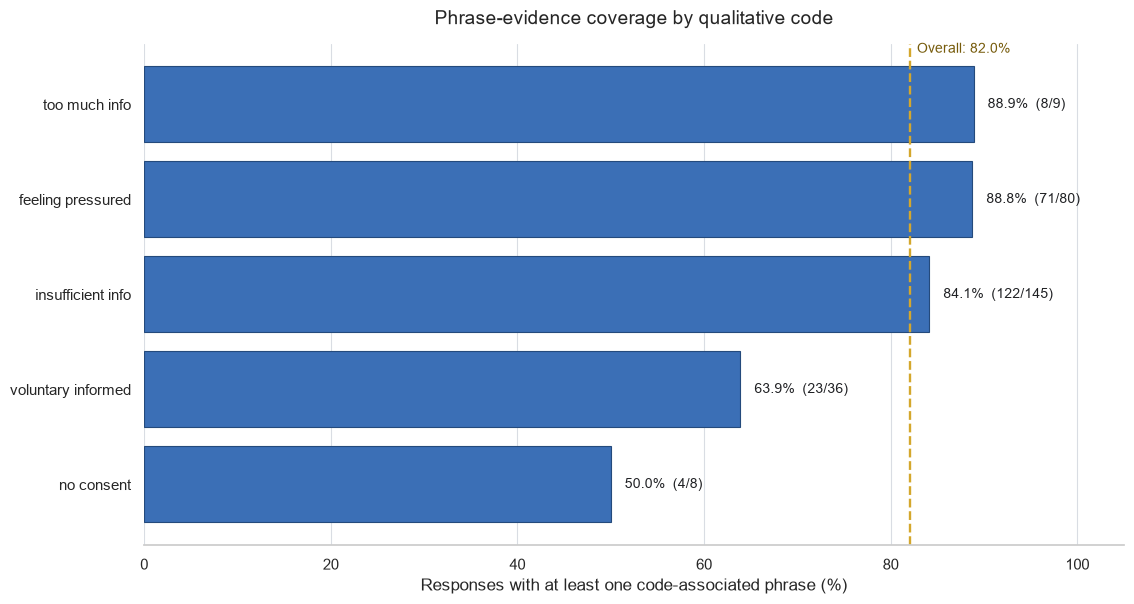

Saved: fig_phrase_evidence_coverage_by_code.png + .pdf


In [6]:
# Figure: response coverage by qualitative code
code_totals = (
    dm_df['code_name']
    .value_counts()
    .reindex(CODE_NAMES)
    .fillna(0)
    .astype(int)
)
covered_counts = (
    phrase_code_top_evidence_df['assigned_code']
    .value_counts()
    .reindex(CODE_NAMES)
    .fillna(0)
    .astype(int)
)

coverage_plot_df = pd.DataFrame({
    'code_name': CODE_NAMES,
    'covered': covered_counts.values,
    'total': code_totals.values,
})
coverage_plot_df['coverage_pct'] = (
    100 * coverage_plot_df['covered'] / coverage_plot_df['total']
)
coverage_plot_df = coverage_plot_df.sort_values('coverage_pct')
overall_coverage = 100 * coverage_plot_df['covered'].sum() / coverage_plot_df['total'].sum()

fig, ax = plt.subplots(figsize=(11.5, 6.2))
bars = ax.barh(
    coverage_plot_df['code_name'].str.replace('_', ' '),
    coverage_plot_df['coverage_pct'],
    color='#3B6FB6',
    edgecolor='#244A7C',
    linewidth=0.8,
)

for bar, row in zip(bars, coverage_plot_df.itertuples(index=False)):
    ax.text(
        min(row.coverage_pct + 1.5, 96),
        bar.get_y() + bar.get_height() / 2,
        f'{row.coverage_pct:.1f}%  ({row.covered}/{row.total})',
        va='center',
        fontsize=10,
        color='#202124',
    )

ax.axvline(overall_coverage, color='#D4A72C', linestyle='--', linewidth=1.7)
ax.text(
    overall_coverage + 0.8,
    len(coverage_plot_df) - 0.35,
    f'Overall: {overall_coverage:.1f}%',
    color='#765B0B',
    fontsize=10,
    va='top',
)
ax.set_xlim(0, 105)
ax.set_xlabel('Responses with at least one code-associated phrase (%)')
ax.set_ylabel('')
ax.set_title('Phrase-evidence coverage by qualitative code', fontsize=14, pad=14)
ax.xaxis.grid(True, color='#D9DDE3', linewidth=0.8)
ax.yaxis.grid(False)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phrase_evidence_coverage_by_code.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig_phrase_evidence_coverage_by_code.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig_phrase_evidence_coverage_by_code.png + .pdf')

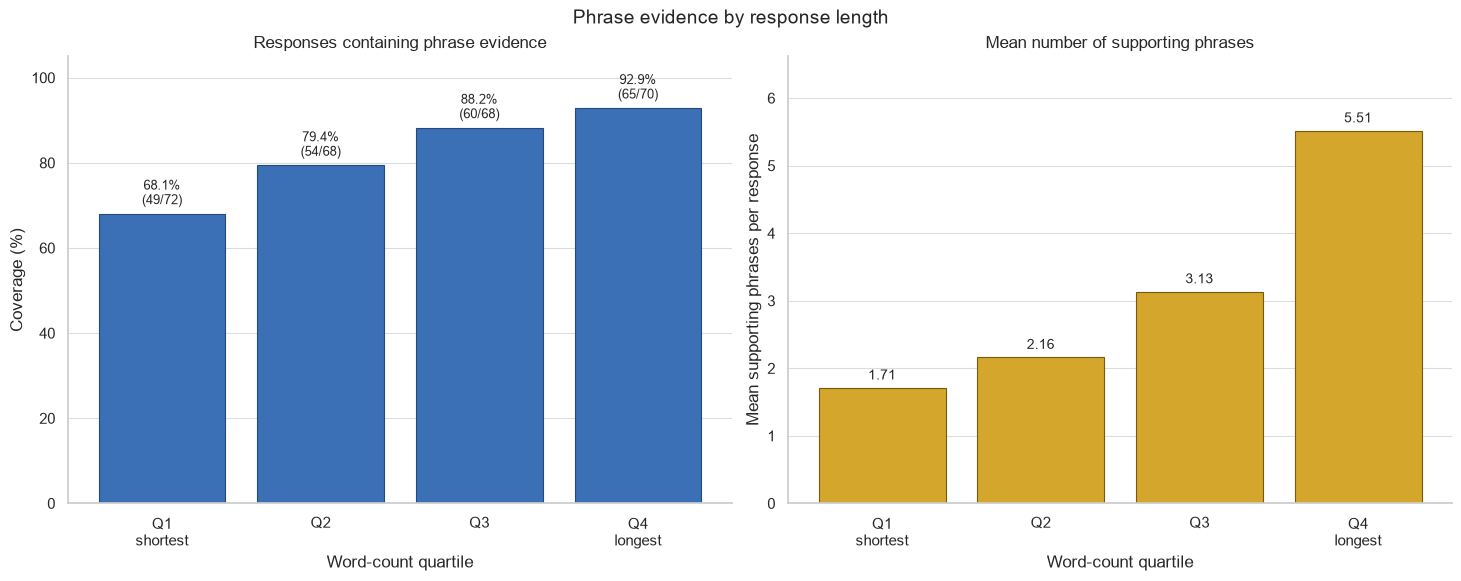

Saved: fig_phrase_evidence_by_response_length.png + .pdf


In [7]:
# Figure: phrase evidence by response-length quartile
response_evidence_plot_df = dm_df.reset_index(names='row_index').merge(
    phrase_code_top_evidence_df[['row_index', 'n_supporting_phrases']],
    on='row_index',
    how='left',
)
response_evidence_plot_df['n_supporting_phrases'] = (
    response_evidence_plot_df['n_supporting_phrases'].fillna(0)
)

quartile_order = ['Q1\nshortest', 'Q2', 'Q3', 'Q4\nlongest']
response_evidence_plot_df['word_count_quartile'] = pd.qcut(
    response_evidence_plot_df['word_count'],
    q=4,
    labels=quartile_order,
)

length_summary = (
    response_evidence_plot_df
    .groupby('word_count_quartile', observed=True)
    .agg(
        responses=('row_index', 'size'),
        covered=('n_supporting_phrases', lambda values: int((values > 0).sum())),
        mean_supporting_phrases=('n_supporting_phrases', 'mean'),
    )
    .reindex(quartile_order)
    .reset_index()
)
length_summary['coverage_pct'] = (
    100 * length_summary['covered'] / length_summary['responses']
)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.7), constrained_layout=True)

coverage_bars = axes[0].bar(
    length_summary['word_count_quartile'],
    length_summary['coverage_pct'],
    color='#3B6FB6',
    edgecolor='#244A7C',
    linewidth=0.8,
)
axes[0].bar_label(
    coverage_bars,
    labels=[
        f'{row.coverage_pct:.1f}%\n({row.covered}/{row.responses})'
        for row in length_summary.itertuples(index=False)
    ],
    padding=4,
    fontsize=9,
)
axes[0].set_ylim(0, 105)
axes[0].set_title('Responses containing phrase evidence', fontsize=12)
axes[0].set_ylabel('Coverage (%)')
axes[0].set_xlabel('Word-count quartile')

mean_bars = axes[1].bar(
    length_summary['word_count_quartile'],
    length_summary['mean_supporting_phrases'],
    color='#D4A72C',
    edgecolor='#765B0B',
    linewidth=0.8,
)
axes[1].bar_label(
    mean_bars,
    labels=[f'{value:.2f}' for value in length_summary['mean_supporting_phrases']],
    padding=4,
    fontsize=10,
)
axes[1].set_ylim(0, length_summary['mean_supporting_phrases'].max() * 1.20)
axes[1].set_title('Mean number of supporting phrases', fontsize=12)
axes[1].set_ylabel('Mean supporting phrases per response')
axes[1].set_xlabel('Word-count quartile')

for ax in axes:
    ax.yaxis.grid(True, color='#D9DDE3', linewidth=0.8)
    ax.xaxis.grid(False)
    sns.despine(ax=ax)

fig.suptitle('Phrase evidence by response length', fontsize=14)
plt.savefig(OUTPUT_DIR / 'fig_phrase_evidence_by_response_length.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig_phrase_evidence_by_response_length.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig_phrase_evidence_by_response_length.png + .pdf')

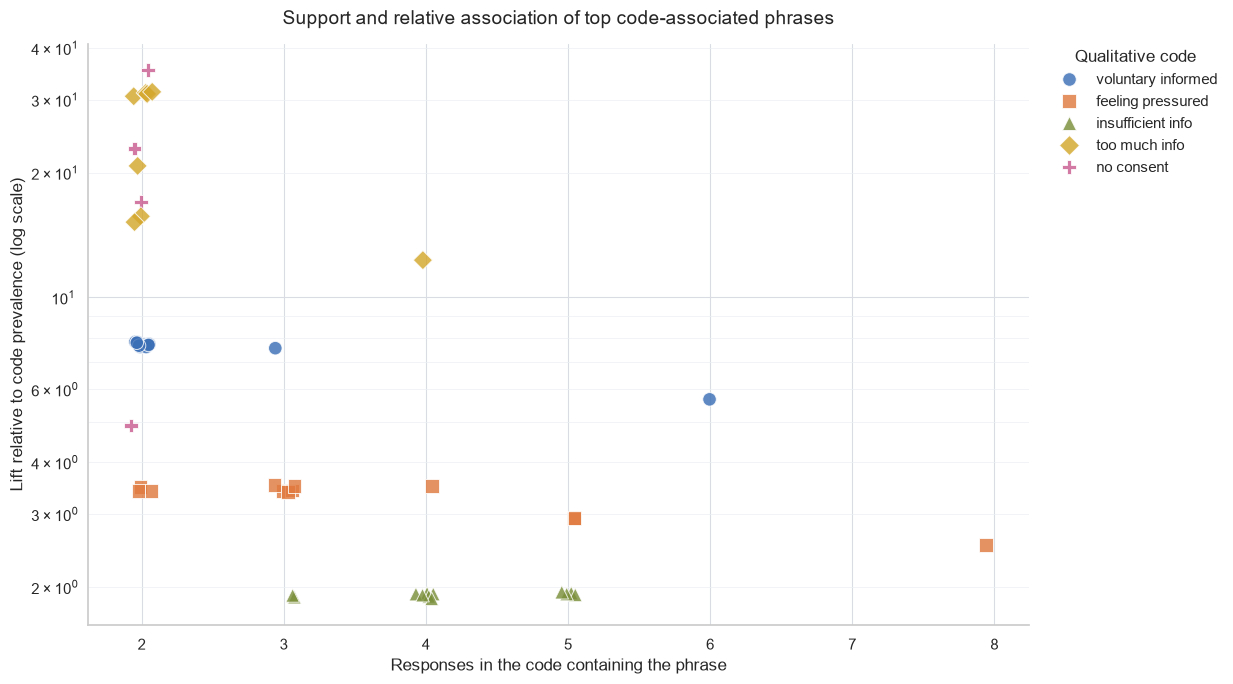

Saved: fig_phrase_support_vs_lift.png + .pdf


In [8]:
# Figure: support and lift among the top retained phrases
support_lift_plot_df = top_phrases_by_code.copy()
# Small deterministic display jitter reveals phrases with identical statistics.
display_rng = np.random.default_rng(42)
support_lift_plot_df['support_display'] = (
    support_lift_plot_df['class_phrase_docs']
    + display_rng.uniform(-0.08, 0.08, len(support_lift_plot_df))
)
support_lift_plot_df['lift_display'] = (
    support_lift_plot_df['lift']
    * np.exp(display_rng.uniform(-0.025, 0.025, len(support_lift_plot_df)))
)

code_palette = {
    'voluntary_informed': '#3B6FB6',
    'feeling_pressured': '#E07A3F',
    'insufficient_info': '#7A8F3A',
    'too_much_info': '#D4A72C',
    'no_consent': '#C95D8F',
}
code_markers = {
    'voluntary_informed': 'o',
    'feeling_pressured': 's',
    'insufficient_info': '^',
    'too_much_info': 'D',
    'no_consent': 'P',
}

fig, ax = plt.subplots(figsize=(12.5, 7.0))
sns.scatterplot(
    data=support_lift_plot_df,
    x='support_display',
    y='lift_display',
    hue='code_name',
    style='code_name',
    hue_order=CODE_NAMES,
    style_order=CODE_NAMES,
    palette=code_palette,
    markers=code_markers,
    s=95,
    alpha=0.82,
    edgecolor='white',
    linewidth=0.7,
    ax=ax,
)

ax.set_yscale('log')
ax.set_xticks(
    range(
        int(support_lift_plot_df['class_phrase_docs'].min()),
        int(support_lift_plot_df['class_phrase_docs'].max()) + 1,
    )
)
ax.set_xlabel('Responses in the code containing the phrase')
ax.set_ylabel('Lift relative to code prevalence (log scale)')
ax.set_title('Support and relative association of top code-associated phrases', fontsize=14, pad=14)
ax.grid(True, which='major', color='#D9DDE3', linewidth=0.8)
ax.grid(True, which='minor', axis='y', color='#ECEFF3', linewidth=0.5)
sns.despine(ax=ax)

legend = ax.legend(
    title='Qualitative code',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False,
)
for text_item in legend.get_texts():
    text_item.set_text(text_item.get_text().replace('_', ' '))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phrase_support_vs_lift.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig_phrase_support_vs_lift.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig_phrase_support_vs_lift.png + .pdf')

## 6. Examples

These rows are not final qualitative claims. They are compact evidence prompts for manual review and writing.


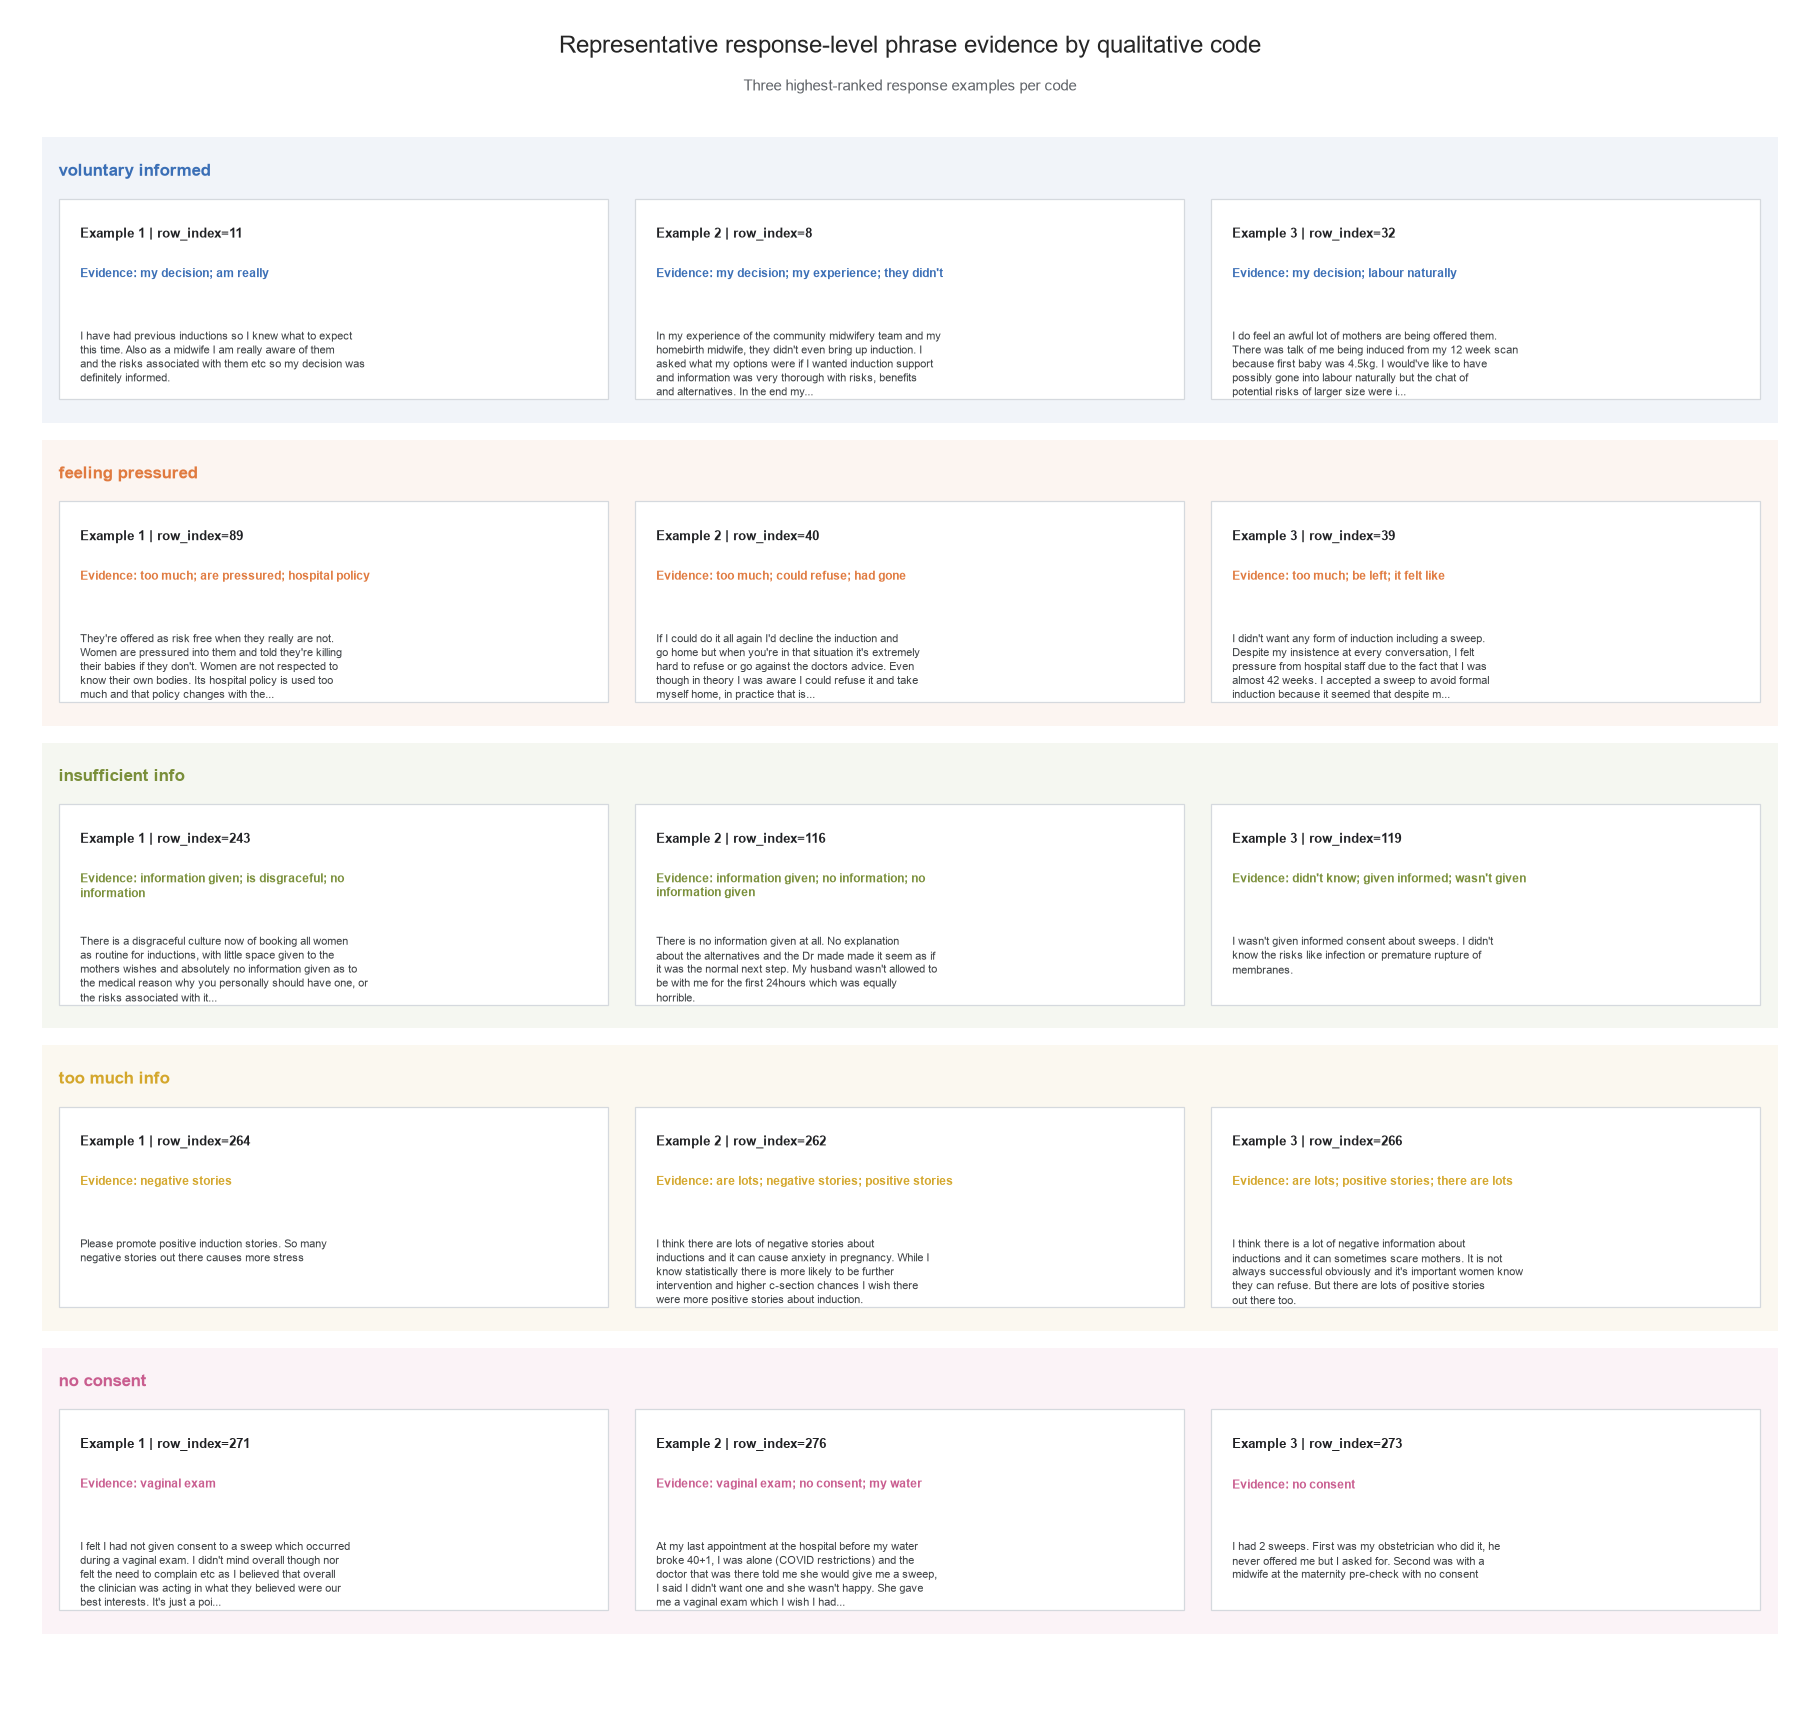

Saved: fig_phrase_code_response_examples.png + .pdf


In [9]:
# Figure: representative response-level phrase evidence
import textwrap
from matplotlib.patches import Rectangle

example_palette = {
    'voluntary_informed': '#3B6FB6',
    'feeling_pressured': '#E07A3F',
    'insufficient_info': '#7A8F3A',
    'too_much_info': '#D4A72C',
    'no_consent': '#C95D8F',
}

fig = plt.figure(figsize=(18, 17), facecolor='white')
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

fig.suptitle(
    'Representative response-level phrase evidence by qualitative code',
    fontsize=17,
    y=0.985,
)
ax.text(
    0.5,
    0.955,
    'Three highest-ranked response examples per code',
    ha='center',
    va='center',
    fontsize=10.5,
    color='#5F6368',
)

band_top_start = 0.925
band_height = 0.168
band_gap = 0.010
cell_width = 0.305
cell_gap = 0.015
left_margin = 0.027

for code_index, code in enumerate(CODE_NAMES):
    subset = (
        phrase_code_top_evidence_df[
            phrase_code_top_evidence_df['assigned_code'] == code
        ]
        .head(3)
        .reset_index(drop=True)
    )

    band_top = band_top_start - code_index * (band_height + band_gap)
    band_bottom = band_top - band_height
    code_color = example_palette[code]

    ax.add_patch(Rectangle(
        (0.018, band_bottom),
        0.964,
        band_height,
        facecolor=code_color,
        edgecolor='none',
        alpha=0.07,
    ))
    ax.text(
        0.027,
        band_top - 0.020,
        code.replace('_', ' '),
        ha='left',
        va='center',
        fontsize=12,
        fontweight='bold',
        color=code_color,
    )

    for example_index, row in enumerate(subset.itertuples(index=False)):
        cell_left = left_margin + example_index * (cell_width + cell_gap)
        cell_bottom = band_bottom + 0.014
        cell_height = band_height - 0.050

        ax.add_patch(Rectangle(
            (cell_left, cell_bottom),
            cell_width,
            cell_height,
            facecolor='white',
            edgecolor='#D5D9DE',
            linewidth=0.9,
        ))

        phrase_list = [
            phrase.strip()
            for phrase in str(row.top_phrases).split(';')
            if phrase.strip()
        ][:3]
        evidence_text = '; '.join(phrase_list)
        response_text = ' '.join(str(row.response_text).split())
        if len(response_text) > 260:
            response_text = response_text[:257].rstrip() + '...'

        ax.text(
            cell_left + 0.012,
            cell_bottom + cell_height - 0.017,
            f'Example {example_index + 1} | row_index={row.row_index}',
            ha='left',
            va='top',
            fontsize=9.2,
            fontweight='bold',
            color='#202124',
        )
        ax.text(
            cell_left + 0.012,
            cell_bottom + cell_height - 0.040,
            'Evidence: ' + textwrap.fill(evidence_text, width=48),
            ha='left',
            va='top',
            fontsize=8.5,
            fontweight='bold',
            color=code_color,
            linespacing=1.25,
        )
        ax.text(
            cell_left + 0.012,
            cell_bottom + cell_height - 0.077,
            textwrap.fill(response_text, width=57),
            ha='left',
            va='top',
            fontsize=8.1,
            color='#3C4043',
            linespacing=1.32,
        )

plt.savefig(
    OUTPUT_DIR / 'fig_phrase_code_response_examples.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
plt.savefig(
    OUTPUT_DIR / 'fig_phrase_code_response_examples.pdf',
    bbox_inches='tight',
    facecolor='white',
)
plt.show()
print('Saved: fig_phrase_code_response_examples.png + .pdf')

## 7. Bridge File for LIME/SHAP Pooling

This small table gives the next notebook a clean join target: one row per phrase and code with human-code association statistics. Can later add LIME/SHAP support flags or attribution scores on the same phrase keys.


In [10]:
bridge_cols = [
    'phrase', 'code_name', 'phrase_len', 'phrase_doc_freq', 'class_phrase_docs',
    'p_code_given_phrase', 'p_code_baseline', 'lift', 'odds_ratio_smoothed',
    'fisher_p', 'association_score'
]
bridge_df = strong_assoc_df[bridge_cols].copy().sort_values(['code_name', 'association_score'], ascending=[True, False])
bridge_df.to_csv(OUTPUT_DIR / 'phrase_code_bridge_for_explanations.csv', index=False)

print(f'Saved bridge file for later LIME/SHAP pooling: {OUTPUT_DIR / "phrase_code_bridge_for_explanations.csv"}')
print(f'Bridge rows: {len(bridge_df)}')
display(bridge_df.head(20))


print('Multiplicity result: no phrase-code association reached BH-FDR q<0.05; all phrase evidence is exploratory and descriptive.')


Saved bridge file for later LIME/SHAP pooling: outputs\phrase_code_bridge_for_explanations.csv
Bridge rows: 349


,phrase,code_name,phrase_len,phrase_doc_freq,class_phrase_docs,p_code_given_phrase,p_code_baseline,lift,odds_ratio_smoothed,fisher_p,association_score
24,too much,feeling_pressured,2,4,4,1.000000,0.28777,3.475000,23.352941,0.006494,1.717723
27,want an induction,feeling_pressured,3,3,3,1.000000,0.28777,3.475000,17.929032,0.023194,1.479566
28,say no,feeling_pressured,2,3,3,1.000000,0.28777,3.475000,17.929032,0.023194,1.479566
29,very hard,feeling_pressured,2,3,3,1.000000,0.28777,3.475000,17.929032,0.023194,1.479566
30,be left,feeling_pressured,2,3,3,1.000000,0.28777,3.475000,17.929032,0.023194,1.479566
31,it felt like,feeling_pressured,3,3,3,1.000000,0.28777,3.475000,17.929032,0.023194,1.479566
34,felt pressured,feeling_pressured,2,6,5,0.833333,0.28777,2.895833,9.591611,0.008334,1.329335
35,it felt,feeling_pressured,2,6,5,0.833333,0.28777,2.895833,9.591611,0.008334,1.329335
37,felt like,feeling_pressured,2,11,8,0.727273,0.28777,2.527273,6.548768,0.002660,1.217272
38,hospital setting,feeling_pressured,2,2,2,1.000000,0.28777,3.475000,12.643312,0.082072,1.172529


Multiplicity result: no phrase-code association reached BH-FDR q<0.05; all phrase evidence is exploratory and descriptive.



Phrase-code association was used to identify textual evidence that was empirically characteristic of each final human code. These phrases do not reveal the coder's internal reasoning, but they indicate that a response contains language disproportionately associated with its assigned category in the labelled dataset.

This is the evidence layer to combine later with LIME and SHAP:

- phrase-code association: phrase is characteristic of the human label;
- LIME/SHAP: phrase influenced the trained model locally;
- human review: phrase is substantively meaningful in context.
